# Faster R-CNN for Pascal VOC 2007 Vehicle Detection

This notebook fine-tunes **Faster R-CNN** on **Pascal VOC 2007** for 4 vehicle classes:

- car
- bus
- motorbike
- bicycle

Designed to run on **Google Colab GPU**.

In [ ]:
# Install dependencies
!pip install -q torchmetrics tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.8 MB/s eta 0:00:00


In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import VOCDetection
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device: cuda


In [ ]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# Configuration
DATA_ROOT = "./data"
BATCH_SIZE = 4
NUM_WORKERS = 2
NUM_EPOCHS = 10
LEARNING_RATE = 0.005
WEIGHT_DECAY = 0.0005
MOMENTUM = 0.9

CLASS_NAMES = ["background", "car", "bus", "motorbike", "bicycle"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
TARGET_CLASSES = set(CLASS_NAMES[1:])

print(CLASS_TO_ID)

{'background': 0, 'car': 1, 'bus': 2, 'motorbike': 3, 'bicycle': 4}


## Dataset

This notebook uses `VOCDetection` from `torchvision`, parses the XML annotations,
and keeps only the target vehicle classes.

Images without target classes are skipped.

In [ ]:
class VOCVehicleDetection(Dataset):
    def __init__(self, root, year="2007", image_set="trainval", transforms=None, download=True):
        self.dataset = VOCDetection(root=root, year=year, image_set=image_set, download=download)
        self.transforms = transforms

        self.valid_indices = []
        for idx in range(len(self.dataset)):
            _, ann = self.dataset[idx]
            objects = ann["annotation"].get("object", [])
            if isinstance(objects, dict):
                objects = [objects]
            has_target = any(obj["name"] in TARGET_CLASSES for obj in objects)
            if has_target:
                self.valid_indices.append(idx)

        print(f"{image_set}: kept {len(self.valid_indices)} / {len(self.dataset)} images")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        image, ann = self.dataset[real_idx]
        objects = ann["annotation"].get("object", [])
        if isinstance(objects, dict):
            objects = [objects]

        boxes = []
        labels = []
        iscrowd = []

        for obj in objects:
            cls_name = obj["name"]
            if cls_name not in TARGET_CLASSES:
                continue

            bbox = obj["bndbox"]
            xmin = float(bbox["xmin"])
            ymin = float(bbox["ymin"])
            xmax = float(bbox["xmax"])
            ymax = float(bbox["ymax"])

            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_TO_ID[cls_name])
            iscrowd.append(int(obj.get("difficult", 0)))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        if len(boxes) > 0:
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        else:
            area = torch.zeros((0,), dtype=torch.float32)

        image_id = torch.tensor([real_idx])

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        image = F.to_tensor(image)

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target

In [ ]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target


class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, image, target):
        if random.random() < self.p:
            _, h, w = image.shape
            image = image.flip(-1)
            boxes = target["boxes"].clone()
            if len(boxes) > 0:
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
                target["boxes"] = boxes
        return image, target


def get_transform(train=True):
    transforms = []
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
    return Compose(transforms)

In [ ]:
full_trainval = VOCVehicleDetection(
    root=DATA_ROOT,
    year="2007",
    image_set="trainval",
    transforms=get_transform(train=True),
    download=True
)

test_dataset = VOCVehicleDetection(
    root=DATA_ROOT,
    year="2007",
    image_set="test",
    transforms=get_transform(train=False),
    download=True
)

val_ratio = 0.2
val_size = int(len(full_trainval) * val_ratio)
train_size = len(full_trainval) - val_size

train_dataset, val_dataset = random_split(
    full_trainval,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Turn off augmentation for validation
val_dataset.dataset.transforms = get_transform(train=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 460M/460M [00:18<00:00, 25.0MB/s]


trainval: kept 1292 / 5011 images


100%|██████████| 451M/451M [00:17<00:00, 25.4MB/s]


test: kept 1309 / 4952 images
Train: 1034
Val: 258
Test: 1309


In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

## Model

Replace the Faster R-CNN classification head to match 5 classes:

- 1 background
- 4 vehicle classes

In [ ]:
def get_model(num_classes):
    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(num_classes=len(CLASS_NAMES))
model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 163MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [ ]:
def train_one_epoch(model, loader, optimizer, device, epoch=None, num_epochs=None):
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(loader, desc=f"Training Epoch {epoch}/{num_epochs}", leave=False)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        running_loss += loss_value
        progress_bar.set_postfix(loss=f"{loss_value:.4f}")

    return running_loss / max(len(loader), 1)


In [ ]:
@torch.no_grad()
def evaluate_map(model, loader, device, desc="Evaluating"):
    model.eval()
    metric = MeanAveragePrecision()

    progress_bar = tqdm(loader, desc=desc, leave=False)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        outputs = model(images)

        preds = []
        gts = []
        for output, target in zip(outputs, targets):
            preds.append({
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": output["labels"].detach().cpu(),
            })
            gts.append({
                "boxes": target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu(),
            })

        metric.update(preds, gts)

    return metric.compute()


## Training

This section tracks:

- training loss
- validation mAP@0.5
- validation mAP@0.5:0.95

In [13]:
train_losses = []
val_map50_list = []
val_map5095_list = []

best_map50 = -1.0
best_path = "best_fasterrcnn_voc2007.pth"

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss = train_one_epoch(
        model, train_loader, optimizer, device,
        epoch=epoch + 1, num_epochs=NUM_EPOCHS
    )
    metrics = evaluate_map(
        model, val_loader, device,
        desc=f"Validation Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    map50 = metrics["map_50"].item()
    map5095 = metrics["map"].item()

    train_losses.append(train_loss)
    val_map50_list.append(map50)
    val_map5095_list.append(map5095)

    if map50 > best_map50:
        best_map50 = map50
        torch.save(model.state_dict(), best_path)

    lr_scheduler.step()
    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {train_loss:.4f} | "
        f"Val mAP@0.5: {map50:.4f} | "
        f"Val mAP@0.5:0.95: {map5095:.4f} | "
        f"Time: {elapsed/60:.2f} min"
    )

print("Best val mAP@0.5:", best_map50)
print("Saved:", best_path)


Training Epoch 1/10:   0%|          | 0/259 [00:00<?, ?it/s]

Validation Epoch 1/10:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [1/10] Loss: 0.3034 | Val mAP@0.5: 0.8202 | Val mAP@0.5:0.95: 0.4417 | Time: 6.80 min


Training Epoch 2/10:   0%|          | 0/259 [00:00<?, ?it/s]

Validation Epoch 2/10:   0%|          | 0/65 [00:00<?, ?it/s]

...

Validation Epoch 9/10:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [9/10] Loss: 0.0916 | Val mAP@0.5: 0.8733 | Val mAP@0.5:0.95: 0.6004 | Time: 6.84 min


Training Epoch 10/10:   0%|          | 0/259 [00:00<?, ?it/s]

Validation Epoch 10/10:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch [10/10] Loss: 0.0916 | Val mAP@0.5: 0.8732 | Val mAP@0.5:0.95: 0.6000 | Time: 6.83 min
Best val mAP@0.5: 0.8764656782150269
Saved: best_fasterrcnn_voc2007.pth


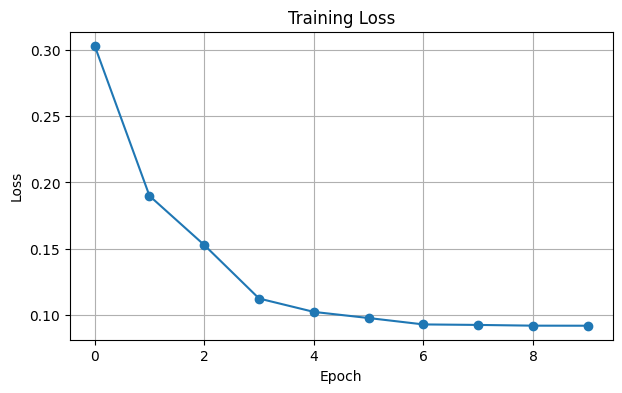

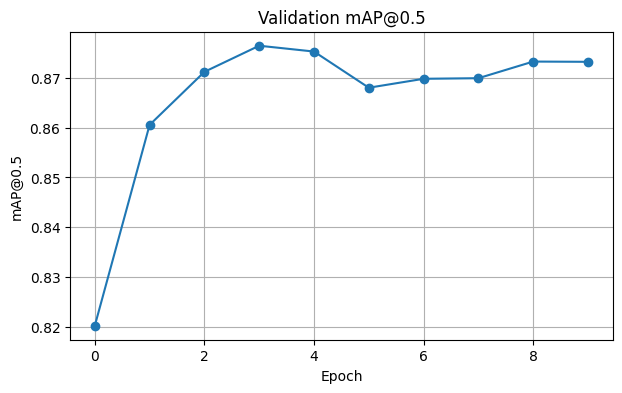

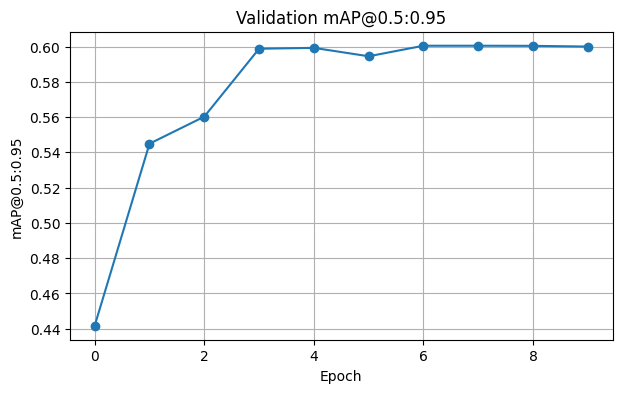

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(val_map50_list, marker="o")
plt.title("Validation mAP@0.5")
plt.xlabel("Epoch")
plt.ylabel("mAP@0.5")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(val_map5095_list, marker="o")
plt.title("Validation mAP@0.5:0.95")
plt.xlabel("Epoch")
plt.ylabel("mAP@0.5:0.95")
plt.grid(True)
plt.show()

## Test Evaluation

Report both:

- **mAP@0.5**
- **mAP@0.5:0.95**

In [15]:
model.load_state_dict(torch.load(best_path, map_location=device))
model.to(device)

test_metrics = evaluate_map(model, test_loader, device, desc="Testing")

test_map50 = test_metrics["map_50"].item()
test_map5095 = test_metrics["map"].item()

print(f"Test mAP@0.5: {test_map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_map5095:.4f}")


Testing:   0%|          | 0/328 [00:00<?, ?it/s]

Test mAP@0.5: 0.8623
Test mAP@0.5:0.95: 0.5862


## Visualization

Visualize a few predictions for the report or slides.

In [22]:
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

@torch.no_grad()
def visualize_predictions(model, dataset, device, num_images=5, score_threshold=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), k=min(num_images, len(dataset)))

    for idx in indices:
        image, _ = dataset[idx]
        pred = model([image.to(device)])[0]

        img_np = image.permute(1, 2, 0).cpu().numpy()
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        ax.imshow(img_np)
        ax.set_axis_off()

        for box, score, label in zip(pred["boxes"].cpu(), pred["scores"].cpu(), pred["labels"].cpu()):
            if score < score_threshold:
                continue
            x1, y1, x2, y2 = box.tolist()
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1, f"{ID_TO_CLASS[int(label)]}: {score:.2f}", fontsize=10)

        plt.show()

visualize_predictions(model, test_dataset, device, num_images=5, score_threshold=0.5)

Output hidden; open in https://colab.research.google.com to view.

# Speed Measurement

Measure inference speed using:



*   FPS
*   seconds per image




In [27]:
import time
import torch
import torchvision
from torch.utils.data import Dataset
from torchvision.datasets import VOCDetection
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_NAMES = ["background", "car", "bus", "motorbike", "bicycle"]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
TARGET_CLASSES = set(CLASS_NAMES[1:])
DATA_ROOT = "./data"

def get_model(num_classes):
    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

Device: cuda


In [28]:
class VOCVehicleDetection(Dataset):
    def __init__(self, root, year="2007", image_set="test", download=False):
        self.dataset = VOCDetection(root=root, year=year, image_set=image_set, download=download)
        self.valid_indices = []

        for idx in range(len(self.dataset)):
            _, ann = self.dataset[idx]
            objects = ann["annotation"].get("object", [])
            if isinstance(objects, dict):
                objects = [objects]
            has_target = any(obj["name"] in TARGET_CLASSES for obj in objects)
            if has_target:
                self.valid_indices.append(idx)

        print(f"{image_set}: kept {len(self.valid_indices)} / {len(self.dataset)} images")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        image, ann = self.dataset[real_idx]

        objects = ann["annotation"].get("object", [])
        if isinstance(objects, dict):
            objects = [objects]

        boxes, labels = [], []
        for obj in objects:
            cls_name = obj["name"]
            if cls_name not in TARGET_CLASSES:
                continue
            bbox = obj["bndbox"]
            xmin = float(bbox["xmin"]); ymin = float(bbox["ymin"])
            xmax = float(bbox["xmax"]); ymax = float(bbox["ymax"])
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_TO_ID[cls_name])

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
        }

        image = F.to_tensor(image)
        return image, target

test_dataset = VOCVehicleDetection(root=DATA_ROOT, year="2007", image_set="test", download=False)

test: kept 1309 / 4952 images


In [29]:
@torch.no_grad()
def measure_fps_from_dataset(model, dataset, device, warmup=3, max_images=10):
    model.eval()

    images = []
    for i in range(min(warmup + max_images, len(dataset))):
        image, _ = dataset[i]
        images.append(image.to(device))

    # warmup
    for i, img in enumerate(images[:warmup]):
        _ = model([img])
        print(f"Warmup {i+1}/{warmup}")

    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.time()
    for i, img in enumerate(images[warmup:]):
        _ = model([img])
        print(f"Processed {i+1}/{len(images[warmup:])}")

    if device.type == "cuda":
        torch.cuda.synchronize()

    total_time = time.time() - start
    num_images = len(images[warmup:])

    fps = num_images / total_time
    sec_per_image = total_time / num_images
    return fps, sec_per_image


In [30]:
# Load best model
model = get_model(num_classes=len(CLASS_NAMES))
model.load_state_dict(torch.load("best_fasterrcnn_voc2007.pth", map_location=device))
model.to(device)
model.eval()
print("Loaded best_fasterrcnn_voc2007.pth")

Loaded best_fasterrcnn_voc2007.pth


In [31]:
# Measure speed
fps, sec_per_image = measure_fps_from_dataset(model, test_dataset, device, warmup=3, max_images=10)
print(f"FPS: {fps:.2f}")
print(f"Seconds / image: {sec_per_image:.4f}")

Warmup 1/3
Warmup 2/3
Warmup 3/3
Processed 1/10
Processed 2/10
Processed 3/10
Processed 4/10
Processed 5/10
Processed 6/10
Processed 7/10
Processed 8/10
Processed 9/10
Processed 10/10
FPS: 7.93
Seconds / image: 0.1262
